## ISSW_Analyze

Definition of the absorption optical depth:
$$
\tau = log({I_0 \over I})
$$

Definition of the absorption Angstrom exponent:
$$
AAE = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import ISSWlib as IS
import pandas as pd
import os
%matplotlib inline

In [2]:
!pwd
!ls -l UCBoulder/Rainier_2

/home/chemistry/LAI_in_snow/ISSW
total 64
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:24 Blank.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:44 Rainier_muir_06-25-25.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:46 Rainier_muir_07-13-25.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:42 Rainier_summit_06-25-25.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:39 Rainier_summit_08-25-25.txt
-rw-r--r-- 1 chemistry chemistry   110 Jul 16 12:45 spectrum_files.txt


In [3]:
# Choose the spectrum folder and load in the list of spectra there
# spectrum_folder = 'Rainier_and_MtCook_comparison/'
# spectrum_folder = 'UPS_Rainier2025-07-03-01/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Adams_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder_Misc/'; filtertype = 'millipore'
# spectrum_folder = 'Ulyana ful/'; filtertype = 'millipore'
# spectrum_folder = 'Ponderosa pine pollen/'; filtertype = 'millipore'
spectrum_folder = 'Rainier dirt/'; filtertype = 'millipore'

# spectrum_folder = 'UPS_2016Chile/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'
# spectrum_folder = 'UPS_INKStandards/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucInc/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucFul/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'

# !ls -l '2026July7'
# !ls -l '2026July7/NucFul'
# !ls -l '2026July7/NucInc'

# Checking location of files
files = os.listdir(spectrum_folder)
print(files)

['Rainier dirt 2.txt', 'Rainier dirt 3.txt', '.ipynb_checkpoints', 'Rainier dirt 1.txt', 'Blank.txt', 'spectrum_files.txt']


In [4]:
# Parameter file
# parameter_filename = 'calibration parameters from UPS_INKStandards (July 13, 2026).csv'
# parameter_filename = 'calibration parameters from 2026July7 NucFul (July 13, 2026).csv'
parameter_filename = 'calibration parameters from Ulyana ful (July 16, 2026).csv'
# parameter_filename = 'calibration parameters from Ulyana ful (July 16, 2026), with iterative adj of AAE.csv'

df = pd.read_csv(parameter_filename)
print(df)
calibration_spectrum_folder = df.at[0, 'calibration_spectrum_folder']
kappa_450 = df.at[0, 'kappa_450']
kappa_600 = df.at[0, 'kappa_600']
R1R2_450 = df.at[0,'R1R2_450']
R1R2_600 = df.at[0,'R1R2_600']
beta_std_450 = df.at[0,'beta_std_450']
beta_std_600 = df.at[0,'beta_std_600']
AAE_std = df.at[0,'AAE_std']

beta1_std = beta_std_450/100
beta2_std = beta_std_600/100

  calibration_spectrum_folder  kappa_450  kappa_600  R1R2_450  R1R2_600  \
0                 Ulyana ful/   1.117577   0.211715  0.849756  0.201356   

   beta_std_450  beta_std_600   AAE_std  
0             2      2.323059 -0.520497  


In [5]:
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  Rainier dirt/spectrum_files.txt , finding these spectra:
      Rainier dirt 1.txt
      Rainier dirt 2.txt
      Rainier dirt 3.txt


In [6]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

lambda_450 =  450.0
lambda_600 =  600.0


In [7]:
# Preallocate arrays and other constants
chi_observed = np.zeros((number_of_loadings,2))
bot = np.log(lambda_nm[I_1]/lambda_nm[I_2])

chi1, chi2 =  0.42016479640644616 0.2821651467483577
chi1, chi2 =  0.7925316924415937 0.6051454670081583
chi1, chi2 =  0.5203205493770859 0.3925972523627294


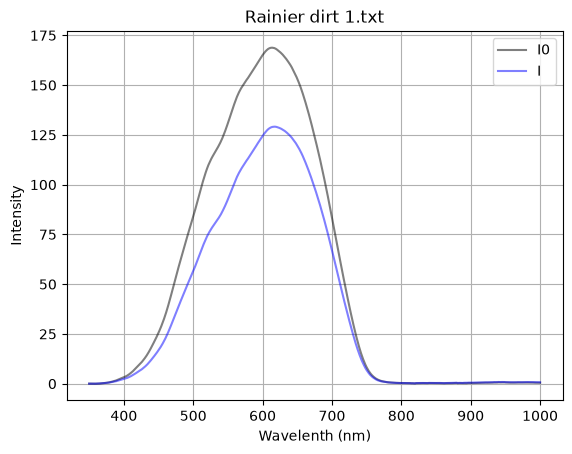

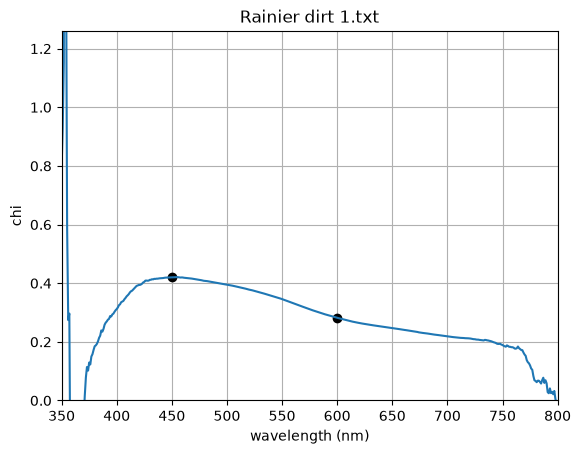

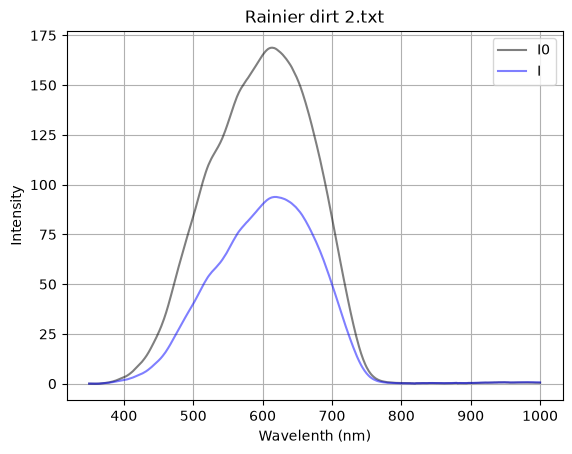

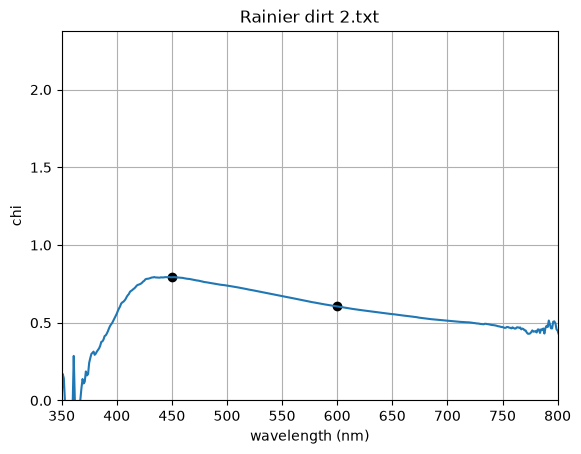

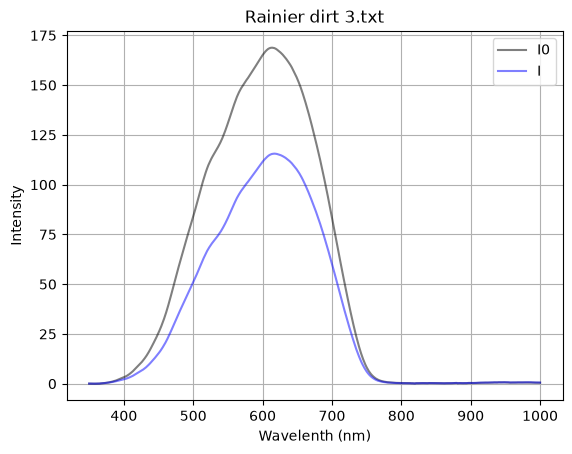

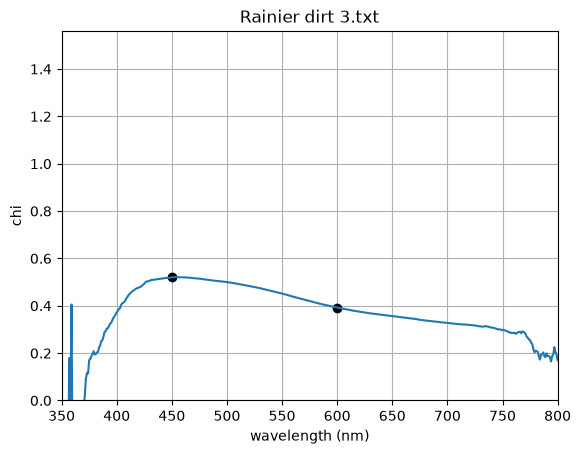

In [8]:
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get the observed chi-values
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    print('chi1, chi2 = ', chi[I_1],chi[I_2])
    
    # Save chi values at lambda1 and lambda2
    chi_observed[i,0] = chi[I_1]
    chi_observed[i,1] = chi[I_2]
    
    # Get the tau values associated with these two points
    tau_1 = IS.invert_chi_theory(chi[I_1],R1R2_450)*kappa_450
    tau_2 = IS.invert_chi_theory(chi[I_2],R1R2_600)*kappa_600
    
    # Get the Angstrom exponent
    top = np.log(tau_1/tau_2)
    AAE = -top/bot
    
    # Record for plotting later
    if i==0:
        AAElist = AAE
        Ilist = I
        tau_1list = tau_1
        tau_2list = tau_2
    else:
        AAElist = np.append(AAElist,AAE)
        Ilist = np.vstack((Ilist,I))
        tau_1list = np.append(tau_1list,tau_1)
        tau_2list = np.append(tau_2list,tau_2)

In [9]:
# Getting equivalent loadings
L_1list = tau_1list/beta1_std
L_2list = tau_2list/beta2_std

# Reporting
print('Loadings and AAE of '+spectrum_folder)
print('Using '+parameter_filename)
for i in range(number_of_loadings):
    print('For ',spectrum_list[i],', L1 =', L_1list[i],', L2 =', L_2list[i],', AAE =', AAElist[i])

Loadings and AAE of Rainier dirt/
Using calibration parameters from Ulyana ful (July 16, 2026).csv
For  Rainier dirt 1.txt , L1 = 1.1826946203393691 , L2 = 0.9194256430833324 , AAE = 0.3547799799193059
For  Rainier dirt 2.txt , L1 = 2.72843165545075 , L2 = 2.1114839296403876 , AAE = 0.3705420254153673
For  Rainier dirt 3.txt , L1 = 1.5447250288601497 , L2 = 1.3119401918066445 , AAE = 0.047278368561821986
